# Validación del Alineamiento

Esta libreta carga `alignment_summary.csv`, visualiza los desplazamientos frame a frame
y detecta posibles frames problemáticos (saltos bruscos, correlación baja).

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ALIGNED_DIR = PROJECT_ROOT / 'data' / 'aligned'
SUMMARY_PATH = ALIGNED_DIR / 'alignment_summary.csv'
CALIBRATED_DIR = PROJECT_ROOT / 'data' / 'reduced' / 'calibrated'

# Ejecutar el alignment con la misma lógica implementada en src/alignment/pipeline.py
from alignment.pipeline import AlignmentPaths, AlignmentConfig, run_alignment_pipeline

align_paths = AlignmentPaths(
    calibrated_dir=CALIBRATED_DIR,
    output_dir=ALIGNED_DIR,
 )
align_config = AlignmentConfig()

result_table = run_alignment_pipeline(align_paths, align_config)
print(f"Frames procesados en alignment: {len(result_table)}")
print(f"Resumen guardado en: {SUMMARY_PATH}")

Frames procesados en alignment: 111
Resumen guardado en: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\data\aligned\alignment_summary.csv


In [ ]:
df = pd.read_csv(SUMMARY_PATH)
df['frame_index'] = range(len(df))

print(f"Frames cargados: {len(df)}")
df.head(25)

Frames cargados: 100


,file,dx,dy,corr_peak,reference_strategy,status,pass1_jump,pass1_low_corr,pass1_corr_drop,rejected,corr_threshold,pass1_shift_error,frame_index
0,cal_tres1-b-002.fit,0.0,0.0,1.000000,median,aligned,0.000000,False,False,False,0.18,False,0
1,cal_tres1-b-003.fit,-0.2,-0.1,0.988778,median,aligned,0.223607,False,False,False,0.18,False,1
2,cal_tres1-b-004.fit,-0.1,-0.3,0.989158,median,aligned,0.223607,False,False,False,0.18,False,2
3,cal_tres1-b-005.fit,-0.2,-0.2,0.997467,median,aligned,0.141421,False,False,False,0.18,False,3
4,cal_tres1-b-006.fit,0.1,-0.4,0.988720,median,aligned,0.360555,False,False,False,0.18,False,4
5,cal_tres1-b-007.fit,0.2,-0.3,0.992836,median,aligned,0.141421,False,False,False,0.18,False,5
6,cal_tres1-b-008.fit,0.2,-0.3,0.997984,median,aligned,0.000000,False,False,False,0.18,False,6
7,cal_tres1-b-009.fit,0.2,-0.6,0.988598,median,aligned,0.300000,False,False,False,0.18,False,7
8,cal_tres1-b-010.fit,0.2,-0.7,0.998242,median,aligned,0.100000,False,False,False,0.18,False,8
9,cal_tres1-b-011.fit,0.2,-1.0,0.993322,median,aligned,0.300000,False,False,False,0.18,False,9


## Desplazamiento dx / dy por frame

Un drift lento es normal (seguimiento del telescopio). Saltos bruscos entre frames
consecutivos indican posible fallo de registro o problema mecánico.

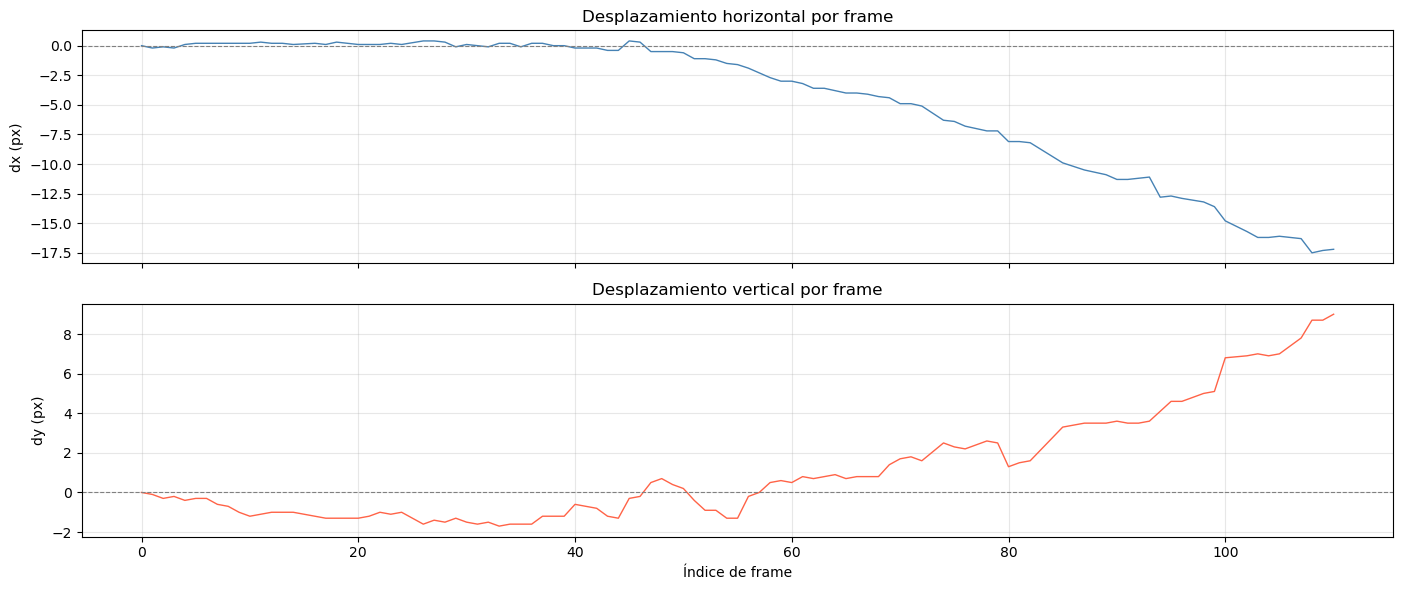

Rango dx: [-17.5, 0.4] px
Rango dy: [-1.7, 9.0] px
Drift total:  dx=-17.2 px  dy=9.0 px


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df['frame_index'], df['dx'], color='steelblue', lw=1)
axes[0].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[0].set_ylabel('dx (px)')
axes[0].set_title('Desplazamiento horizontal por frame')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['frame_index'], df['dy'], color='tomato', lw=1)
axes[1].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[1].set_ylabel('dy (px)')
axes[1].set_title('Desplazamiento vertical por frame')
axes[1].set_xlabel('Índice de frame')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rango dx: [{df['dx'].min():.1f}, {df['dx'].max():.1f}] px")
print(f"Rango dy: [{df['dy'].min():.1f}, {df['dy'].max():.1f}] px")
print(f"Drift total:  dx={df['dx'].iloc[-1] - df['dx'].iloc[0]:.1f} px  "
      f"dy={df['dy'].iloc[-1] - df['dy'].iloc[0]:.1f} px")

## Mapa de trayectoria 2D del drift

Posición acumulada del centroide de la imagen a lo largo de la noche.

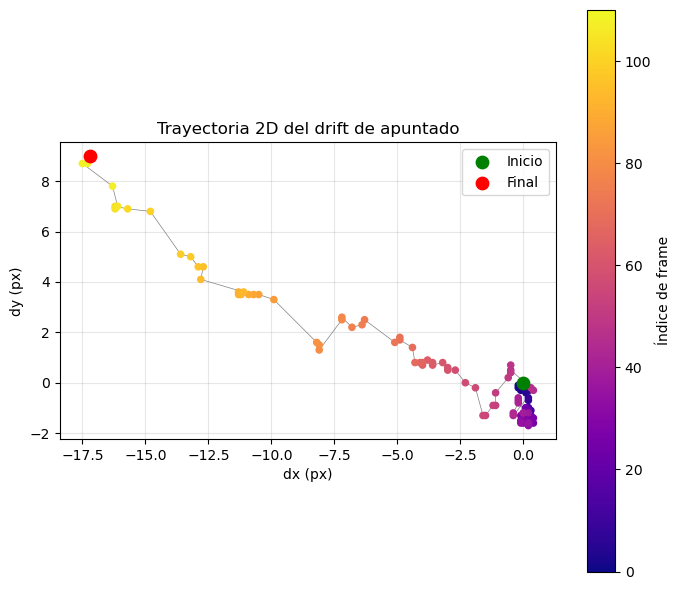

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(df['dx'], df['dy'],
                c=df['frame_index'], cmap='plasma', s=20, zorder=3)
ax.plot(df['dx'], df['dy'], color='gray', lw=0.5, zorder=2)
ax.scatter(df['dx'].iloc[0],  df['dy'].iloc[0],  color='green', s=80,
           zorder=5, label='Inicio')
ax.scatter(df['dx'].iloc[-1], df['dy'].iloc[-1], color='red',   s=80,
           zorder=5, label='Final')

plt.colorbar(sc, ax=ax, label='Índice de frame')
ax.set_xlabel('dx (px)')
ax.set_ylabel('dy (px)')
ax.set_title('Trayectoria 2D del drift de apuntado')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Inspección visual: frame alineado vs referencia

Carga dos frames alineados y los muestra en mosaico para verificar visualmente el registro.

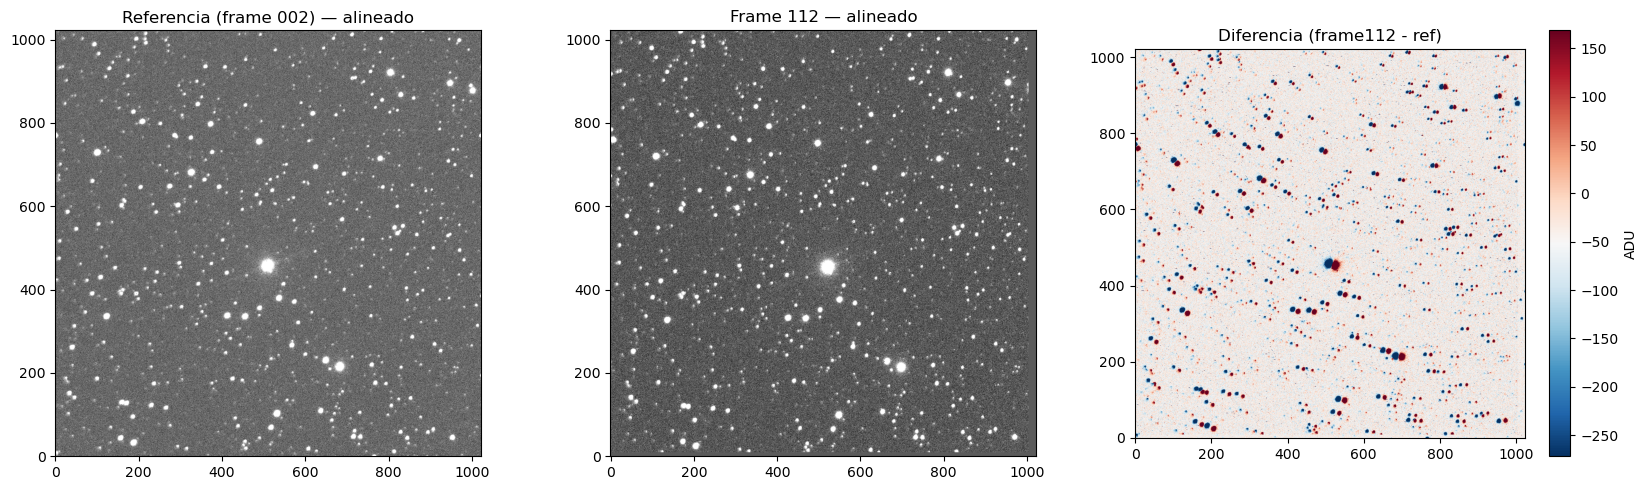

In [5]:
import reduction.io as reduction_io
importlib.reload(reduction_io)
from astropy.visualization import ZScaleInterval

zscale = ZScaleInterval()


frame_ref  = reduction_io.load_ccd(str(ALIGNED_DIR / 'ali_cal_tres1-b-002.fit'))
frame_late = reduction_io.load_ccd(str(ALIGNED_DIR / 'ali_cal_tres1-b-112.fit'))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

vmin, vmax = zscale.get_limits(frame_ref.data)
axes[0].imshow(frame_ref.data,  cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
axes[0].set_title('Referencia (frame 002) — alineado')

vmin2, vmax2 = zscale.get_limits(frame_late.data)
axes[1].imshow(frame_late.data, cmap='gray', vmin=vmin2, vmax=vmax2, origin='lower')
axes[1].set_title('Frame 112 — alineado')

diff = frame_late.data.astype(float) - frame_ref.data.astype(float)
vd1, vd2 = np.percentile(diff, [1, 99])
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=vd1, vmax=vd2, origin='lower')
axes[2].set_title('Diferencia (frame112 - ref)')
plt.colorbar(im, ax=axes[2], label='ADU')

plt.tight_layout()
plt.show()

## Resumen de calidad del alineamiento

Pares causales detectados (corr_baja[N] -> salto[N+1]): 0


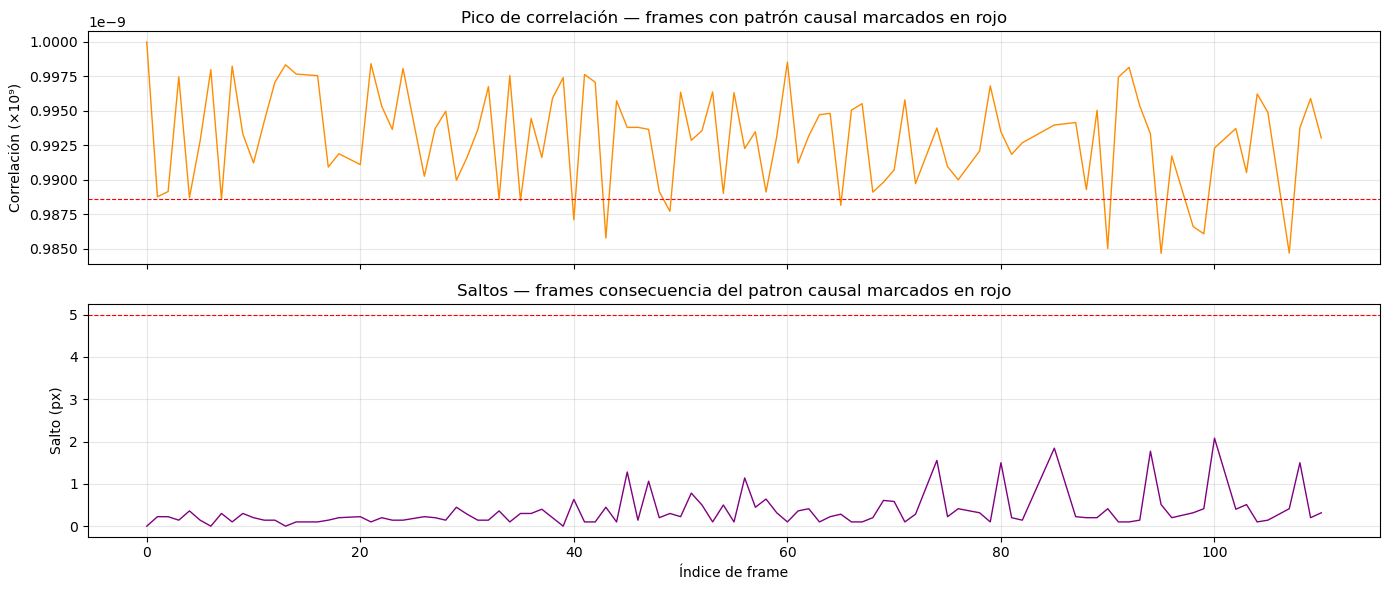


Frames candidatos a descartar por patron causal: []


In [6]:
# Patron causal: frame con correlacion baja seguido de salto en el siguiente
# Si frame N tiene corr_peak < umbral Y frame N+1 tiene jump > umbral,
# el shift de N es probablemente erroneo y N es el frame a descartar.

JUMP_THRESHOLD = 5.0  # píxeles — ajustable
CORR_LOW_THRESHOLD = df['corr_peak'].quantile(0.10)  # percentil 10 como umbral bajo

low_corr_idx = set(df[df['corr_peak'] < CORR_LOW_THRESHOLD]['frame_index'])
jump_idx = set(df[df['pass1_jump'] > JUMP_THRESHOLD]['frame_index'])

# Frame N con corr baja cuyo sucesor N+1 tiene salto
causal_pairs = [(i, i+1) for i in low_corr_idx if (i + 1) in jump_idx]

# Tambien: frame con salto cuyo predecesor tiene corr baja (mismo patron, deteccion inversa)
bad_frames = sorted(set([i for i, _ in causal_pairs]))

print(f"Pares causales detectados (corr_baja[N] -> salto[N+1]): {len(causal_pairs)}")
for n, n1 in causal_pairs:
    corr_n  = df.loc[df['frame_index'] == n,  'corr_peak'].values[0]
    jump_n1 = df.loc[df['frame_index'] == n1, 'pass1_jump'].values[0]
    file_n  = df.loc[df['frame_index'] == n,  'file'].values[0]
    print(f"  Frame {n:3d} ({file_n}): corr={corr_n/1e9:.2f}e9  ->  salto frame {n1}: {jump_n1:.1f} px")

# Visualizacion combinada
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df['frame_index'], df['corr_peak'] / 1e9, color='darkorange', lw=1)
axes[0].axhline(CORR_LOW_THRESHOLD / 1e9, color='red', linestyle='--', lw=0.8)
for i in bad_frames:
    axes[0].axvspan(i - 0.5, i + 0.5, color='red', alpha=0.25)
axes[0].set_ylabel('Correlación (×10⁹)')
axes[0].set_title('Pico de correlación — frames con patrón causal marcados en rojo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['frame_index'], df['pass1_jump'], color='purple', lw=1)
axes[1].axhline(JUMP_THRESHOLD, color='red', linestyle='--', lw=0.8)
for _, n1 in causal_pairs:
    axes[1].axvspan(n1 - 0.5, n1 + 0.5, color='red', alpha=0.25)
axes[1].set_ylabel('Salto (px)')
axes[1].set_title('Saltos — frames consecuencia del patron causal marcados en rojo')
axes[1].set_xlabel('Índice de frame')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFrames candidatos a descartar por patron causal: {bad_frames}")

In [9]:
total = len(df)
n_suspicious = len(df[df['pass1_jump'] > JUMP_THRESHOLD])
n_low_corr   = len(df[df['corr_peak'] < CORR_LOW_THRESHOLD])
n_ok         = total - len(df[(df['pass1_jump'] > JUMP_THRESHOLD) | (df['corr_peak'] < CORR_LOW_THRESHOLD)])

print(f"Total frames alineados : {total}")
print(f"Frames OK              : {n_ok}  ({100*n_ok/total:.1f}%)")
print(f"Salto brusco (>{JUMP_THRESHOLD} px)  : {n_suspicious}")
print(f"Correlación baja (p10) : {n_low_corr}")
print(f"Drift total acumulado  : dx={df['dx'].iloc[-1]:.1f} px  dy={df['dy'].iloc[-1]:.1f} px")

Total frames alineados : 100
Frames OK              : 90  (90.0%)
Salto brusco (>5.0 px)  : 0
Correlación baja (p10) : 10
Drift total acumulado  : dx=-17.2 px  dy=9.0 px


Punto de ruptura detectado en frame 77 (cal_tres1-b-084.fit)
Delta acumulado en ese frame: 0.98 px

--- TRAMO ESTABLE ---
Frames: 73 (cal_tres1-b-002.fit a cal_tres1-b-078.fit)
dx rango: [-6.8, 0.4] px
dy rango: [-1.7, 2.5] px
dx std: 1.97 px
dy std: 1.08 px

--- TRAMO INESTABLE ---
Frames: 27 (cal_tres1-b-080.fit a cal_tres1-b-112.fit)
dx rango: [-17.5, -7.2] px
dy rango: [1.3, 9.0] px
Salto neto: dx=-0.4 px, dy=0.4 px


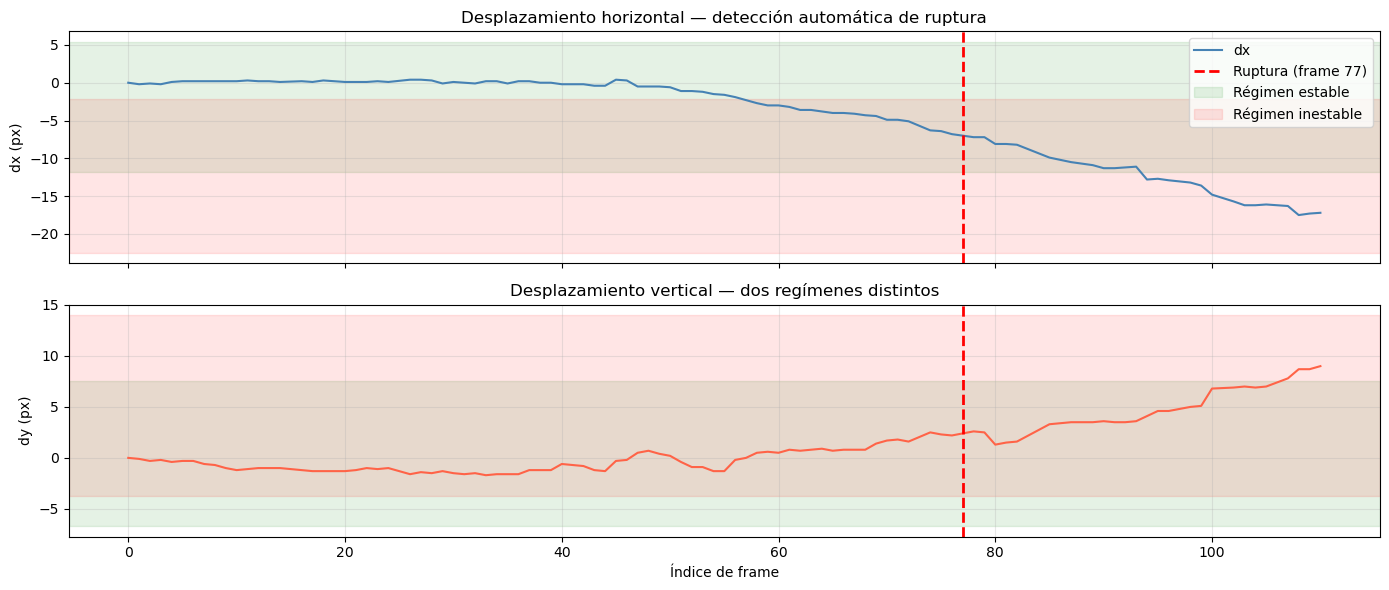


→ Recomendación: usar frames 0-76 para fotometría principal (régimen estable)
→ Si necesitas frames 77+, realinear ese bloque con referencia propia


In [10]:

# Detección automática del punto de ruptura usando cambio en dx/dy
# Busca el frame donde ocurre un salto abrupto en el desplazamiento

import numpy as np

# Calcular cambio incremental en desplazamiento
ddx = np.abs(np.diff(df['dx'].values, prepend=df['dx'].iloc[0]))
ddy = np.abs(np.diff(df['dy'].values, prepend=df['dy'].iloc[0]))
total_delta = np.sqrt(ddx**2 + ddy**2)

# Ventana móvil para detectar cambio de régimen
window_size = 5
cumul_delta = np.convolve(total_delta, np.ones(window_size)/window_size, mode='same')

# Threshold: detección cuando el delta sale de lo "normal"
threshold = np.percentile(cumul_delta[:50], 75)  # usa primeros 50 frames como referencia estable
breakpoint_idx = np.where(cumul_delta > 3*threshold)[0]

if len(breakpoint_idx) > 0:
    breakpoint = breakpoint_idx[0]
    print(f"Punto de ruptura detectado en frame {breakpoint} ({df.loc[breakpoint, 'file']})")
    print(f"Delta acumulado en ese frame: {cumul_delta[breakpoint]:.2f} px")
else:
    breakpoint = len(df)
    print("No se detectó ruptura clara; asumiendo noche estable.")

# Dividir en dos tramos
stable_frames = df[df['frame_index'] < breakpoint].copy()
unstable_frames = df[df['frame_index'] >= breakpoint].copy() if breakpoint < len(df) else pd.DataFrame()

print(f"\n--- TRAMO ESTABLE ---")
print(f"Frames: {len(stable_frames)} ({stable_frames['file'].iloc[0]} a {stable_frames['file'].iloc[-1]})")
print(f"dx rango: [{stable_frames['dx'].min():.1f}, {stable_frames['dx'].max():.1f}] px")
print(f"dy rango: [{stable_frames['dy'].min():.1f}, {stable_frames['dy'].max():.1f}] px")
print(f"dx std: {stable_frames['dx'].std():.2f} px")
print(f"dy std: {stable_frames['dy'].std():.2f} px")

if len(unstable_frames) > 0:
    print(f"\n--- TRAMO INESTABLE ---")
    print(f"Frames: {len(unstable_frames)} ({unstable_frames['file'].iloc[0]} a {unstable_frames['file'].iloc[-1]})")
    print(f"dx rango: [{unstable_frames['dx'].min():.1f}, {unstable_frames['dx'].max():.1f}] px")
    print(f"dy rango: [{unstable_frames['dy'].min():.1f}, {unstable_frames['dy'].max():.1f}] px")
    print(f"Salto neto: dx={unstable_frames['dx'].iloc[0] - stable_frames['dx'].iloc[-1]:.1f} px, "
          f"dy={unstable_frames['dy'].iloc[0] - stable_frames['dy'].iloc[-1]:.1f} px")

# Visualizar regímenes
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df['frame_index'], df['dx'], color='steelblue', lw=1.5, label='dx')
axes[0].axvline(breakpoint, color='red', linestyle='--', lw=2, label=f'Ruptura (frame {breakpoint})')
if len(stable_frames) > 0:
    axes[0].axhspan(stable_frames['dx'].min()-5, stable_frames['dx'].max()+5, alpha=0.1, color='green', label='Régimen estable')
if len(unstable_frames) > 0:
    axes[0].axhspan(unstable_frames['dx'].min()-5, unstable_frames['dx'].max()+5, alpha=0.1, color='red', label='Régimen inestable')
axes[0].set_ylabel('dx (px)')
axes[0].set_title('Desplazamiento horizontal — detección automática de ruptura')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['frame_index'], df['dy'], color='tomato', lw=1.5, label='dy')
axes[1].axvline(breakpoint, color='red', linestyle='--', lw=2)
if len(stable_frames) > 0:
    axes[1].axhspan(stable_frames['dy'].min()-5, stable_frames['dy'].max()+5, alpha=0.1, color='green')
if len(unstable_frames) > 0:
    axes[1].axhspan(unstable_frames['dy'].min()-5, unstable_frames['dy'].max()+5, alpha=0.1, color='red')
axes[1].set_ylabel('dy (px)')
axes[1].set_xlabel('Índice de frame')
axes[1].set_title('Desplazamiento vertical — dos regímenes distintos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n→ Recomendación: usar frames 0-{breakpoint-1} para fotometría principal (régimen estable)")
if len(unstable_frames) > 0:
    print(f"→ Si necesitas frames {breakpoint}+, realinear ese bloque con referencia propia")
